ML 1

Maria Nowacka 275981
Dominik Hołoś 

In [ ]:
!pip install scikit-learn matplotlib xgboost pandas

In [19]:
import sklearn as sk, numpy as np, matplotlib.pyplot as plt
cool_number = 17 # random state

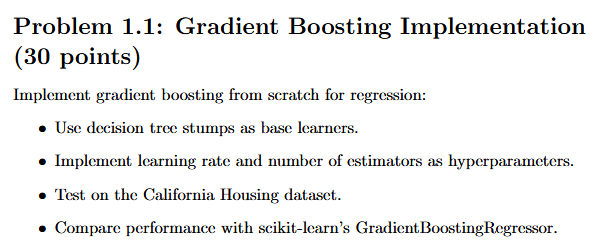


- loss function: MSE $L(y, f(x)) = \frac{1}{2}(y-F(x))^2 $
- weak learners: h(x) - decision stumps (dec tree with depth 1)
Fitting algorithm:
1. calculate initial prediction $F_0= \frac{1}{n} \sum^n_{i=1} y_i = \bar{y}$
2. for j=1, 2, ..., M:
    - compute residuals: $r_{i, j} = y_i - F_{j-1}(x_i) => (r_{1,j}, ..., r_{n,j})$
    - fit a weak learner $h_j(x)$ to residuals
        tree = DecisionTreeRegressor(mx_depth=1)
        tree.fit(X, residuals)
    - update the ensemble $F_j(x) = F_{j-1}(x) + \eta h_j(x)$, $\eta$ - learning rate
    
Final model: $F(x) = F_0(x) + \eta \sum^n_{}j=1 h_j(x) $

How to calculate a prediction for a new point x* from the fitted model? '.predict()'

$F(x*) = F_0(x)\ [still\ \bar{y}\ for\ training\ set] + \eta \sum^m_{j=1} h_j(x*)\ [we\ need\ all\ weak\ learners]$

- compare with gradient boosting regressor (with the same n_estimators, learning_rate, max_depth=1)

In [20]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor

class CustomGradientBoosting:
    def __init__(self, n_estimators=100, learning_rate=0.1):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.trees = []
        self.f0 = None

    def fit(self, X, y):
        # 1. Initialize with mean (F0)
        self.f0 = np.mean(y)
        F = np.full(len(y), self.f0)
        
        for m in range(self.n_estimators):
            # 2. Compute residuals
            residuals = y - F
            
            # 3. Fit a stump (max_depth=1)
            tree = DecisionTreeRegressor(max_depth=1, random_state=m)
            tree.fit(X, residuals)
            
            # 4. Update the ensemble
            update = tree.predict(X)
            F += self.learning_rate * update
            
            # Store the tree
            self.trees.append(tree)

    def predict(self, X):
        # Start with the initial mean
        y_pred = np.full(len(X), self.f0)
        
        # Add contributions from each tree scaled by learning_rate
        for tree in self.trees:
            y_pred += self.learning_rate * tree.predict(X)
            
        return y_pred
# Load Dataset
data = fetch_california_housing()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=cool_number)

# Hyperparameters
n_estimators = [50, 100]
l_rates = [0.1, 0.01]
for n_est in n_estimators:
    for lr in l_rates:

        # --- Custom Model ---
        custom_gb = CustomGradientBoosting(n_estimators=n_est, learning_rate=lr)
        custom_gb.fit(X_train, y_train)
        custom_preds = custom_gb.predict(X_test)
        custom_mse = mean_squared_error(y_test, custom_preds)

        # --- Sklearn Model ---
        sklearn_gb = GradientBoostingRegressor(n_estimators=n_est, learning_rate=lr, max_depth=1, random_state=cool_number)
        sklearn_gb.fit(X_train, y_train)
        sklearn_preds = sklearn_gb.predict(X_test)
        sklearn_mse = mean_squared_error(y_test, sklearn_preds)

        print(f"--- Performance Comparison:  --- \n n_estimator = {n_est}, learning rate = {lr} ")
        print(f"Custom GB MSE:  {custom_mse}")
        print(f"Sklearn GB MSE: {sklearn_mse}")
        print(f"Difference:     {abs(custom_mse - sklearn_mse)}")


--- Performance Comparison:  --- 
 n_estimator = 50, learning rate = 0.1 
Custom GB MSE:  0.570274756155501
Sklearn GB MSE: 0.5702747561555008
Difference:     2.220446049250313e-16
--- Performance Comparison:  --- 
 n_estimator = 50, learning rate = 0.01 
Custom GB MSE:  1.0310183067377863
Sklearn GB MSE: 1.0310183067377867
Difference:     4.440892098500626e-16
--- Performance Comparison:  --- 
 n_estimator = 100, learning rate = 0.1 
Custom GB MSE:  0.47091540124022996
Sklearn GB MSE: 0.4709154012402298
Difference:     1.6653345369377348e-16
--- Performance Comparison:  --- 
 n_estimator = 100, learning rate = 0.01 
Custom GB MSE:  0.8857197430211828
Sklearn GB MSE: 0.885719743021183
Difference:     1.1102230246251565e-16


MSE for most cases is almost the same for both custom implementation and sklearn, there are insignificant difference (e-16) - implementation is of high quality.

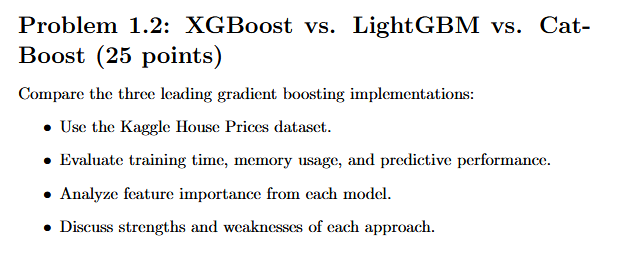

In [17]:
# dataset kaggle house prices
# categorical variables as categories - data preprocessing so the comparison is fair
# log-transfor for y (and then back to what it is with exp)

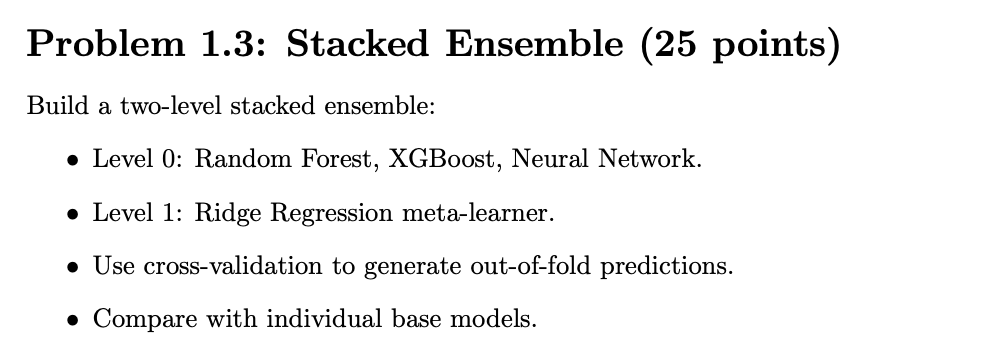

- dataset: California Housing (see problem 1.1)
- divide dataset into training and test sets
- prepeare data (bc we us NN), features' standarization is required (eg standard scaler)
- consider base models:
    - random forest regression
    - XGB regressor
    - MLP regessor
- get out-of-fold predictions
    - split training datasets into k-folds ($D_1, D_2, D_3, ..., D_K$)
    - for each fold $D_k$:
        - train each base model on $D \backslash D_k$
        - predict on $D_k$
    - collect all out-of-fold predictions (array of size n\_train $x^3$)
- train meta-model (Ridge) on meta-features:
    x - out-of-fold predictions,
    y - y_train
- compare the stacked ensemble with individual base models (predictive performance)
- check meta-model's coefficients (weights)


In [18]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

# Load and Split
data = fetch_california_housing()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=cool_number)

# Scaling (Crucial for MLP and Ridge)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Initialize Base Models
models = {
    "RF": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=cool_number),
    "XGB": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=cool_number),
    "MLP": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=cool_number)
}

kf = KFold(n_splits=5, shuffle=True, random_state=cool_number)
oof_train = np.zeros((X_train.shape[0], len(models)))
oof_test_list = {name: [] for name in models.keys()}

# K-Fold Loop
for train_idx, val_idx in kf.split(X_train_scaled):
    X_fold_train, X_fold_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
    
    for i, (name, model) in enumerate(models.items()):
        # Train on K-1 folds
        model.fit(X_fold_train, y_fold_train)
        
        # Predict on the held-out fold
        oof_train[val_idx, i] = model.predict(X_fold_val)
        
        # Predict on actual test set for final evaluation later
        oof_test_list[name].append(model.predict(X_test_scaled))

# Average the test set predictions from each fold
oof_test = np.column_stack([np.mean(oof_test_list[name], axis=0) for name in models.keys()])

# Train Meta-Model
meta_model = Ridge(alpha=1.0)
meta_model.fit(oof_train, y_train)

# Final Ensemble Prediction
ensemble_preds = meta_model.predict(oof_test)

results = {}

# Evaluate individual base models (using their average fold predictions)
for i, name in enumerate(models.keys()):
    mse = mean_squared_error(y_test, oof_test[:, i])
    results[name] = mse

# Evaluate Stacked Ensemble
ensemble_mse = mean_squared_error(y_test, ensemble_preds)
results["Stacked Ensemble"] = ensemble_mse

print("--- Predictive Performance (MSE) ---")
for name, mse in results.items():
    print(f"{name:16}: {mse:.4f}")

print("\n--- Meta-Model Coefficients (Weights) ---")
for name, coef in zip(models.keys(), meta_model.coef_):
    print(f"{name:16}: {coef:.4f}")

--- Predictive Performance (MSE) ---
RF              : 0.3075
XGB             : 0.2306
MLP             : 0.2802
Stacked Ensemble: 0.2244

--- Meta-Model Coefficients (Weights) ---
RF              : -0.2267
XGB             : 0.9961
MLP             : 0.2310


Stacked Ensemble approach outperformed *all* individual base models, achieving the lowest MSE (comparing to the base models). 

Weight tell us what the model relays on the most - in this case XGB, due to its high individual accuracy, then MPL (meaning it captured patterns in the data that the tree-based models might have missed) and RF with negative weight, which implies the meta-model uses RF's predictions to counteract systematic biases or correlated errors present in the other models.